# Phase 3 — Major-Conference Endgame Scoring Analysis

Same snapshot-based PPM methodology as `02_analysis.ipynb`, but:
1. **Filtered to Power 6** conference games (ACC, Big 12, Big East, Big Ten, Pac-12, SEC)
2. **SOS-adjusted** defensive efficiency via iterative KenPom-style ratings

---

## 0 — Setup & Load Data

In [51]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import os, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

SEASON = 2024
DATA_DIR = os.path.join(os.getcwd(), 'data')

pbp      = pq.read_table(os.path.join(DATA_DIR, f'pbp_{SEASON}.parquet')).to_pandas()
team_box = pq.read_table(os.path.join(DATA_DIR, f'team_box_{SEASON}.parquet')).to_pandas()
schedule = pq.read_table(os.path.join(DATA_DIR, f'schedule_{SEASON}.parquet')).to_pandas()

print(f'PBP:      {pbp.shape[0]:>10,} rows  ({pbp["game_id"].nunique():,} games)')
print(f'Team Box: {team_box.shape[0]:>10,} rows  ({team_box["game_id"].nunique():,} games)')
print(f'Schedule: {schedule.shape[0]:>10,} rows')

PBP:       2,004,997 rows  (6,151 games)
Team Box:     12,480 rows  (6,240 games)
Schedule:      6,249 rows


---
## 1 — Conference Mapping & Power 6 Filter

In [52]:
# ── Build team -> conference mapping from schedule ──
gmap = schedule[['groups_id', 'groups_short_name', 'groups_name']].drop_duplicates().dropna()
gmap['groups_id'] = gmap['groups_id'].astype(int)
conf_id_to_name = gmap.set_index('groups_id')['groups_short_name'].to_dict()

home = schedule[['home_id', 'home_conference_id']].rename(
    columns={'home_id': 'team_id', 'home_conference_id': 'conf_id'})
away = schedule[['away_id', 'away_conference_id']].rename(
    columns={'away_id': 'team_id', 'away_conference_id': 'conf_id'})
all_teams = pd.concat([home, away]).dropna(subset=['conf_id'])
all_teams['conf_id'] = all_teams['conf_id'].astype(int)

team_conf = all_teams.groupby('team_id')['conf_id'].agg(
    lambda x: x.mode().iloc[0]).reset_index()
team_conf['conf'] = team_conf['conf_id'].map(conf_id_to_name)

POWER_6 = ['ACC', 'Big 12', 'Big East', 'Big Ten', 'Pac-12', 'SEC']
p6_teams = team_conf[team_conf['conf'].isin(POWER_6)]
p6_ids = set(p6_teams['team_id'])

print(f'Total teams mapped: {len(team_conf):,}')
print(f'Power 6 teams: {len(p6_teams)}')
for c in POWER_6:
    print(f'  {c:<10} {(p6_teams["conf"]==c).sum():>3} teams')

Total teams mapped: 362
Power 6 teams: 80
  ACC         15 teams
  Big 12      14 teams
  Big East    11 teams
  Big Ten     14 teams
  Pac-12      12 teams
  SEC         14 teams


In [53]:
# ── Filter PBP to P6-vs-P6 games ──
# Identify games where both home & away are P6
p6_games = schedule[
    schedule['home_id'].isin(p6_ids) & schedule['away_id'].isin(p6_ids)
]['game_id'].unique()

pbp_p6 = pbp[pbp['game_id'].isin(p6_games)].copy()
n_p6_games = pbp_p6['game_id'].nunique()

print(f'P6-vs-P6 games: {n_p6_games:,} / {pbp["game_id"].nunique():,} total')
print(f'P6 PBP events:  {len(pbp_p6):,} / {len(pbp):,} total')

P6-vs-P6 games: 1,041 / 6,151 total
P6 PBP events:  338,777 / 2,004,997 total


---
## 2 — Prepare Regulation Data

In [54]:
# ── Filter to regulation, convert types, compute margin ──
reg = pbp_p6[pbp_p6['period_number'].isin([1, 2])].copy()
reg['home_score'] = pd.to_numeric(reg['home_score'], errors='coerce').fillna(0).astype(int)
reg['away_score'] = pd.to_numeric(reg['away_score'], errors='coerce').fillna(0).astype(int)
reg['score_value'] = pd.to_numeric(reg['score_value'], errors='coerce').fillna(0).astype(int)
reg['secs_remaining'] = pd.to_numeric(reg['end_game_seconds_remaining'], errors='coerce')
reg['margin'] = reg['home_score'] - reg['away_score']
reg = reg.sort_values(['game_id', 'sequence_number']).reset_index(drop=True)
reg['scorer_is_home'] = reg['team_id'] == reg['home_team_id']
reg['scorer_venue'] = np.where(reg['scorer_is_home'], 'Home', 'Away')

n_games = reg['game_id'].nunique()
print(f'P6 regulation events: {len(reg):,}  ({n_games:,} games)')

P6 regulation events: 335,045  (1,041 games)


In [55]:
# ── Margin buckets ──
def margin_bucket(m):
    if pd.isna(m): return None
    m = int(m)
    if   m > 15:          return 'Leading >15'
    elif 10 <= m <= 15:   return 'Leading 10-15'
    elif 5  <= m <= 9:    return 'Leading 5-9'
    elif 1  <= m <= 4:    return 'Leading 1-4'
    elif m == 0:          return 'Tied'
    elif -4 <= m <= -1:   return 'Trailing 1-4'
    elif -9 <= m <= -5:   return 'Trailing 5-9'
    elif -15 <= m <= -10: return 'Trailing 10-15'
    else:                 return 'Trailing >15'

BUCKET_ORDER = [
    'Leading >15', 'Leading 10-15', 'Leading 5-9', 'Leading 1-4',
    'Tied',
    'Trailing 1-4', 'Trailing 5-9', 'Trailing 10-15', 'Trailing >15'
]
print('Margin buckets ready.')

Margin buckets ready.


---
## 3 — SOS-Adjusted Defensive Efficiency

Iterative KenPom-style adjustment using **all games** (full schedule),
then quartile assignment on the **P6 subset** only.

$$\text{adj\_def}_{t}^{(k+1)} = \text{raw\_def}_{t} \times \frac{\text{league avg off}}{\text{mean}(\text{adj\_off}_{\text{opponents}}^{(k)})}$$

In [56]:
# ── Raw efficiency from ALL games (full schedule) ──
tb = team_box.copy()
for col in ['field_goals_attempted', 'offensive_rebounds', 'turnovers',
            'free_throws_attempted', 'team_score', 'opponent_team_score']:
    tb[col] = pd.to_numeric(tb[col], errors='coerce')

tb['possessions'] = (
    tb['field_goals_attempted'] - tb['offensive_rebounds']
    + tb['turnovers'] + 0.475 * tb['free_throws_attempted']
)
tb['off_eff'] = np.where(tb['possessions'] > 0,
                          tb['team_score'] / tb['possessions'] * 100, np.nan)
tb['def_eff'] = np.where(tb['possessions'] > 0,
                          tb['opponent_team_score'] / tb['possessions'] * 100, np.nan)

# Season-level raw efficiency
team_stats = tb.groupby('team_id').agg(
    total_pts=('team_score', 'sum'),
    total_opp_pts=('opponent_team_score', 'sum'),
    total_poss=('possessions', 'sum'),
    games=('game_id', 'nunique'),
    team_name=('team_display_name', 'first'),
).reset_index()

team_stats['raw_off'] = team_stats['total_pts'] / team_stats['total_poss'] * 100
team_stats['raw_def'] = team_stats['total_opp_pts'] / team_stats['total_poss'] * 100

# Filter to teams with >= 10 games for stability
team_stats = team_stats[team_stats['games'] >= 10].copy()
print(f'Teams with >= 10 games: {len(team_stats)}')
print(f'League avg off eff: {team_stats["raw_off"].mean():.1f}')
print(f'League avg def eff: {team_stats["raw_def"].mean():.1f}')

Teams with >= 10 games: 362
League avg off eff: 106.0
League avg def eff: 103.9


In [57]:
# ── Build opponent schedule for SOS adjustment ──
# For each team-game, identify the opponent
tb_slim = tb[['game_id', 'team_id']].copy()
# Each game has 2 rows in team_box; merge to find opponent
opp_map = tb_slim.merge(tb_slim, on='game_id', suffixes=('', '_opp'))
opp_map = opp_map[opp_map['team_id'] != opp_map['team_id_opp']]

# Build dict: team_id -> list of opponent team_ids
opp_lists = opp_map.groupby('team_id')['team_id_opp'].apply(list).to_dict()

print(f'Opponent schedules built for {len(opp_lists)} teams')

Opponent schedules built for 717 teams


In [58]:
# ── Iterative SOS adjustment ──
league_avg = team_stats['raw_off'].mean()  # ~100

# Initialize adjusted = raw
team_stats['adj_off'] = team_stats['raw_off'].copy()
team_stats['adj_def'] = team_stats['raw_def'].copy()

ts = team_stats.set_index('team_id')

N_ITER = 15
for iteration in range(N_ITER):
    new_adj_off = ts['raw_off'].copy()
    new_adj_def = ts['raw_def'].copy()
    
    for tid in ts.index:
        opps = opp_lists.get(tid, [])
        # Filter to opponents that are in our stable set
        valid_opps = [o for o in opps if o in ts.index]
        if len(valid_opps) == 0:
            continue
        
        # Adjust offense: scale by opponent defense strength
        mean_opp_def = ts.loc[valid_opps, 'adj_def'].mean()
        new_adj_off[tid] = ts.loc[tid, 'raw_off'] * (league_avg / mean_opp_def)
        
        # Adjust defense: scale by opponent offense strength
        mean_opp_off = ts.loc[valid_opps, 'adj_off'].mean()
        new_adj_def[tid] = ts.loc[tid, 'raw_def'] * (league_avg / mean_opp_off)
    
    delta_off = (new_adj_off - ts['adj_off']).abs().max()
    delta_def = (new_adj_def - ts['adj_def']).abs().max()
    
    ts['adj_off'] = new_adj_off
    ts['adj_def'] = new_adj_def
    
    if iteration < 3 or iteration == N_ITER - 1:
        print(f'Iter {iteration+1:>2}: max delta off={delta_off:.4f}  def={delta_def:.4f}')

team_stats = ts.reset_index()
print(f'\nConverged. Adj off range: {team_stats["adj_off"].min():.1f} - {team_stats["adj_off"].max():.1f}')
print(f'Adj def range: {team_stats["adj_def"].min():.1f} - {team_stats["adj_def"].max():.1f}')

Iter  1: max delta off=5.6350  def=5.8684
Iter  2: max delta off=3.2849  def=3.9666
Iter  3: max delta off=3.7084  def=2.3160
Iter 15: max delta off=3.0606  def=0.2546

Converged. Adj off range: 97.4 - 151.0
Adj def range: 71.9 - 104.6


In [59]:
# ── Assign defense quartiles from P6 subset only ──
p6_stats = team_stats[team_stats['team_id'].isin(p6_ids)].copy()
print(f'P6 teams with adjusted ratings: {len(p6_stats)}')

p6_stats['def_quartile'] = pd.qcut(
    p6_stats['adj_def'], q=4,
    labels=['Q1 (Elite)', 'Q2', 'Q3', 'Q4 (Weak)']
)

print(f'\n=== P6 Defense Quartiles (SOS-Adjusted) ===')
print(p6_stats['def_quartile'].value_counts().sort_index().to_string())
print(f'\n=== Adj Def Eff by Quartile ===')
print(p6_stats.groupby('def_quartile')['adj_def'].describe()[['mean','min','max']].round(1).to_string())

print(f'\n=== Top 10 P6 Defenses (SOS-Adjusted) ===')
display(p6_stats.nsmallest(10, 'adj_def')[['team_name','adj_def','raw_def','games','def_quartile']])

print(f'\n=== Bottom 10 P6 Defenses ===')
display(p6_stats.nlargest(10, 'adj_def')[['team_name','adj_def','raw_def','games','def_quartile']])

P6 teams with adjusted ratings: 80

=== P6 Defense Quartiles (SOS-Adjusted) ===
def_quartile
Q1 (Elite)    20
Q2            20
Q3            20
Q4 (Weak)     20

=== Adj Def Eff by Quartile ===
              mean   min   max
def_quartile                  
Q1 (Elite)    79.4  71.9  81.7
Q2            83.4  81.7  84.9
Q3            85.8  84.9  86.7
Q4 (Weak)     89.8  86.9  97.0

=== Top 10 P6 Defenses (SOS-Adjusted) ===


,team_name,adj_def,raw_def,games,def_quartile
115,Houston Cougars,71.948833,89.081090,37,Q1 (Elite)
34,Iowa State Cyclones,73.645042,90.272065,37,Q1 (Elite)
319,Tennessee Volunteers,76.805440,95.955701,36,Q1 (Elite)
0,Auburn Tigers,78.703838,96.112875,35,Q1 (Elite)
18,UConn Huskies,78.863430,96.056968,40,Q1 (Elite)
5,Arizona Wildcats,79.083834,96.758551,36,Q1 (Elite)
61,Michigan State Spartans,79.263805,98.763323,35,Q1 (Elite)
191,UCF Knights,79.456570,97.757720,33,Q1 (Elite)
82,Rutgers Scarlet Knights,79.491304,96.722168,32,Q1 (Elite)
228,Kansas Jayhawks,79.830986,99.612200,34,Q1 (Elite)



=== Bottom 10 P6 Defenses ===


,team_name,adj_def,raw_def,games,def_quartile
148,DePaul Blue Demons,96.979834,119.525735,32,Q4 (Weak)
22,Georgetown Hoyas,96.587861,114.961883,32,Q4 (Weak)
49,Louisville Cardinals,92.230788,111.788618,32,Q4 (Weak)
62,Michigan Wolverines,91.302361,113.489186,32,Q4 (Weak)
66,Missouri Tigers,91.200644,111.226433,32,Q4 (Weak)
111,Vanderbilt Commodores,90.801108,111.401698,32,Q4 (Weak)
133,West Virginia Mountaineers,90.008160,111.244317,32,Q4 (Weak)
31,Georgia Tech Yellow Jackets,89.821005,108.595856,32,Q4 (Weak)
11,California Golden Bears,89.148676,108.040586,32,Q4 (Weak)
67,Ole Miss Rebels,88.893045,107.521993,32,Q4 (Weak)


---
## 4 — Snapshot-Based PPM (P6 Games Only)

In [60]:
# ── Entry margins at each window ──
def get_entry_margins(reg_df, window_secs):
    pre = reg_df[reg_df['secs_remaining'] >= window_secs]
    return pre.groupby('game_id').last()['margin']

entry_10 = get_entry_margins(reg, 600).apply(margin_bucket)
entry_5  = get_entry_margins(reg, 300).apply(margin_bucket)
entry_3  = get_entry_margins(reg, 180).apply(margin_bucket)

print(f'P6 games with entry data: F10={len(entry_10)}, F5={len(entry_5)}, F3={len(entry_3)}')
print(f'\n=== Entry Margin Distribution at 3:00 (P6 Only) ===')
for b in BUCKET_ORDER:
    cnt = (entry_3 == b).sum()
    print(f'  {b:<20} {cnt:>5} games ({100*cnt/len(entry_3):5.1f}%)')

P6 games with entry data: F10=1041, F5=1041, F3=1041

=== Entry Margin Distribution at 3:00 (P6 Only) ===
  Leading >15            192 games ( 18.4%)
  Leading 10-15          159 games ( 15.3%)
  Leading 5-9            117 games ( 11.2%)
  Leading 1-4            129 games ( 12.4%)
  Tied                    98 games (  9.4%)
  Trailing 1-4            86 games (  8.3%)
  Trailing 5-9           104 games ( 10.0%)
  Trailing 10-15          80 games (  7.7%)
  Trailing >15            76 games (  7.3%)


In [61]:
# ── Snapshot PPM function ──
def compute_snapshot_ppm(reg_df, entry_buckets, window_secs, label):
    window_mins = window_secs / 60
    scoring = reg_df[(reg_df['scoring_play']==True) & (reg_df['secs_remaining']<=window_secs)].copy()
    scoring['entry_bucket'] = scoring['game_id'].map(entry_buckets)
    scoring = scoring.dropna(subset=['entry_bucket'])
    pts_by = scoring.groupby('entry_bucket')['score_value'].sum()
    games_by = entry_buckets.value_counts()
    rows = []
    for b in BUCKET_ORDER:
        pts = pts_by.get(b, 0)
        n_g = games_by.get(b, 0)
        ppm = pts / (n_g * window_mins) if n_g > 0 else 0
        rows.append({'Window': label, 'Margin Bucket': b, 'Games': n_g,
                     'Total Pts': int(pts), 'PPM': round(ppm, 3)})
    return rows, scoring

r10, s10 = compute_snapshot_ppm(reg, entry_10, 600, 'Final 10 min')
r5,  s5  = compute_snapshot_ppm(reg, entry_5,  300, 'Final 5 min')
r3,  s3  = compute_snapshot_ppm(reg, entry_3,  180, 'Final 3 min')

scoring_all = {'Final 10 min': s10, 'Final 5 min': s5, 'Final 3 min': s3}
entry_all = {'Final 10 min': entry_10, 'Final 5 min': entry_5, 'Final 3 min': entry_3}

# Add opponent defense quartile
def_lookup = p6_stats.set_index('team_id')['def_quartile'].to_dict()
for key, sdf in scoring_all.items():
    sdf['opp_team_id'] = np.where(sdf['scorer_is_home'], sdf['away_team_id'], sdf['home_team_id'])
    sdf['opp_def_quartile'] = sdf['opp_team_id'].map(def_lookup)

print('PPM computed for all windows.')

PPM computed for all windows.


---
## 5 — PPM Tables (P6 Only)

In [62]:
# ── TABLE A: PPM by Entry Margin x Window ──
table_a = pd.DataFrame(r10 + r5 + r3)
print(f'=== TABLE A: PPM by Entry Margin x Window (P6 Only, {n_games} games) ===\n')
pivot_a = table_a.pivot_table(index='Margin Bucket', columns='Window', values='PPM', sort=False
    ).reindex(BUCKET_ORDER)[['Final 10 min','Final 5 min','Final 3 min']]
display(pivot_a)

=== TABLE A: PPM by Entry Margin x Window (P6 Only, 1041 games) ===



Window,Final 10 min,Final 5 min,Final 3 min
Margin Bucket,,,
Leading >15,4.154,4.244,4.344
Leading 10-15,4.225,4.758,5.516
Leading 5-9,4.137,4.953,5.895
Leading 1-4,4.199,4.535,5.028
Tied,4.178,4.191,4.503
Trailing 1-4,4.134,4.487,5.326
Trailing 5-9,4.058,4.663,5.478
Trailing 10-15,4.085,4.622,5.167
Trailing >15,4.158,4.062,4.110


In [63]:
# ── TABLE A Detail ──
display(table_a)

,Window,Margin Bucket,Games,Total Pts,PPM
0,Final 10 min,Leading >15,176,7311,4.154
1,Final 10 min,Leading 10-15,142,6000,4.225
2,Final 10 min,Leading 5-9,167,6908,4.137
3,Final 10 min,Leading 1-4,113,4745,4.199
4,Final 10 min,Tied,32,1337,4.178
5,Final 10 min,Trailing 1-4,153,6325,4.134
6,Final 10 min,Trailing 5-9,119,4829,4.058
7,Final 10 min,Trailing 10-15,79,3227,4.085
8,Final 10 min,Trailing >15,60,2495,4.158
9,Final 5 min,Leading >15,173,3671,4.244


In [64]:
# ── TABLE B: PPM by Entry Margin x Home/Away ──
def table_b_rows(sdf, eb, ws, wl):
    wm = ws / 60
    gb = eb.value_counts()
    rows = []
    for b in BUCKET_ORDER:
        n_g = gb.get(b, 0)
        be = sdf[sdf['entry_bucket'] == b]
        for v in ['Home', 'Away']:
            pts = be[be['scorer_venue'] == v]['score_value'].sum()
            ppm = pts / (n_g * wm) if n_g > 0 else 0
            rows.append({'Window': wl, 'Margin Bucket': b, 'Venue': v,
                         'Total Pts': int(pts), 'PPM': round(ppm, 3)})
    return rows

tb_data = []
for wl, ws, eb, sd in [('Final 10 min',600,entry_10,s10),
                        ('Final 5 min',300,entry_5,s5),
                        ('Final 3 min',180,entry_3,s3)]:
    tb_data += table_b_rows(sd, eb, ws, wl)
table_b = pd.DataFrame(tb_data)

for wl in ['Final 10 min', 'Final 5 min', 'Final 3 min']:
    print(f'\n=== TABLE B: PPM by Entry Margin x Home/Away ({wl}) ===')
    p = table_b[table_b['Window']==wl].pivot_table(index='Margin Bucket',
        columns='Venue', values='PPM', sort=False).reindex(BUCKET_ORDER)[['Home','Away']]
    p['Delta'] = p['Home'] - p['Away']
    display(p)


=== TABLE B: PPM by Entry Margin x Home/Away (Final 10 min) ===


Venue,Home,Away,Delta
Margin Bucket,,,
Leading >15,2.047,2.107,-0.060
Leading 10-15,2.079,2.146,-0.067
Leading 5-9,2.087,2.049,0.038
Leading 1-4,2.150,2.049,0.101
Tied,2.206,1.972,0.234
Trailing 1-4,2.116,2.018,0.098
Trailing 5-9,2.085,1.973,0.112
Trailing 10-15,2.116,1.968,0.148
Trailing >15,2.128,2.030,0.098



=== TABLE B: PPM by Entry Margin x Home/Away (Final 5 min) ===


Venue,Home,Away,Delta
Margin Bucket,,,
Leading >15,2.071,2.173,-0.102
Leading 10-15,2.343,2.415,-0.072
Leading 5-9,2.535,2.418,0.117
Leading 1-4,2.343,2.192,0.151
Tied,2.100,2.091,0.009
Trailing 1-4,2.279,2.208,0.071
Trailing 5-9,2.434,2.229,0.205
Trailing 10-15,2.413,2.209,0.204
Trailing >15,2.097,1.965,0.132



=== TABLE B: PPM by Entry Margin x Home/Away (Final 3 min) ===


Venue,Home,Away,Delta
Margin Bucket,,,
Leading >15,2.026,2.318,-0.292
Leading 10-15,2.656,2.860,-0.204
Leading 5-9,3.040,2.855,0.185
Leading 1-4,2.742,2.287,0.455
Tied,2.306,2.197,0.109
Trailing 1-4,2.678,2.647,0.031
Trailing 5-9,2.731,2.747,-0.016
Trailing 10-15,2.679,2.488,0.191
Trailing >15,2.237,1.873,0.364


In [65]:
# ── TABLE C: PPM by Entry Margin x Opp Defense Quartile (SOS-Adjusted) ──
def table_c_rows(sdf, eb, ws, wl):
    wm = ws / 60
    gb = eb.value_counts()
    swd = sdf.dropna(subset=['opp_def_quartile'])
    rows = []
    for b in BUCKET_ORDER:
        n_g = gb.get(b, 0)
        be = swd[swd['entry_bucket'] == b]
        for q in ['Q1 (Elite)','Q2','Q3','Q4 (Weak)']:
            pts = be[be['opp_def_quartile']==q]['score_value'].sum()
            ppm = pts / (n_g * wm) if n_g > 0 else 0
            rows.append({'Window': wl, 'Margin Bucket': b, 'Opp Defense': q,
                         'Total Pts': int(pts), 'PPM': round(ppm, 3)})
    return rows

tc_data = []
for wl, ws, eb, sd in [('Final 10 min',600,entry_10,s10),
                        ('Final 5 min',300,entry_5,s5),
                        ('Final 3 min',180,entry_3,s3)]:
    tc_data += table_c_rows(sd, eb, ws, wl)
table_c = pd.DataFrame(tc_data)

for wl in ['Final 3 min', 'Final 5 min']:
    print(f'\n=== TABLE C: PPM x Opp SOS-Adj Defense ({wl}) ===')
    p = table_c[table_c['Window']==wl].pivot_table(index='Margin Bucket',
        columns='Opp Defense', values='PPM', sort=False
    ).reindex(BUCKET_ORDER)[['Q1 (Elite)','Q2','Q3','Q4 (Weak)']]
    display(p)


=== TABLE C: PPM x Opp SOS-Adj Defense (Final 3 min) ===


Opp Defense,Q1 (Elite),Q2,Q3,Q4 (Weak)
Margin Bucket,,,,
Leading >15,1.233,0.991,0.993,1.127
Leading 10-15,1.352,1.476,1.350,1.338
Leading 5-9,1.499,1.350,1.667,1.379
Leading 1-4,0.984,1.439,1.455,1.150
Tied,1.058,1.007,1.190,1.248
Trailing 1-4,1.388,1.442,1.512,0.984
Trailing 5-9,1.381,1.131,1.574,1.391
Trailing 10-15,1.333,1.288,1.233,1.312
Trailing >15,0.803,0.952,0.991,1.364



=== TABLE C: PPM x Opp SOS-Adj Defense (Final 5 min) ===


Opp Defense,Q1 (Elite),Q2,Q3,Q4 (Weak)
Margin Bucket,,,,
Leading >15,1.214,0.953,0.901,1.177
Leading 10-15,1.187,1.140,1.341,1.091
Leading 5-9,1.188,1.365,1.312,1.088
Leading 1-4,0.810,1.436,1.174,1.116
Tied,1.332,0.732,1.195,0.932
Trailing 1-4,1.006,1.008,1.402,1.071
Trailing 5-9,1.476,1.027,1.209,0.951
Trailing 10-15,0.918,1.162,1.176,1.367
Trailing >15,0.781,0.959,0.927,1.395


---
## 6 — Visualizations

In [66]:
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0', 'xtick.color': '#e0e0e0', 'ytick.color': '#e0e0e0',
    'font.size': 11, 'axes.titlesize': 14, 'figure.titlesize': 16,
})
COLORS = {'Final 10 min':'#4cc9f0','Final 5 min':'#f72585','Final 3 min':'#7209b7'}
print('Plot style set.')

Plot style set.


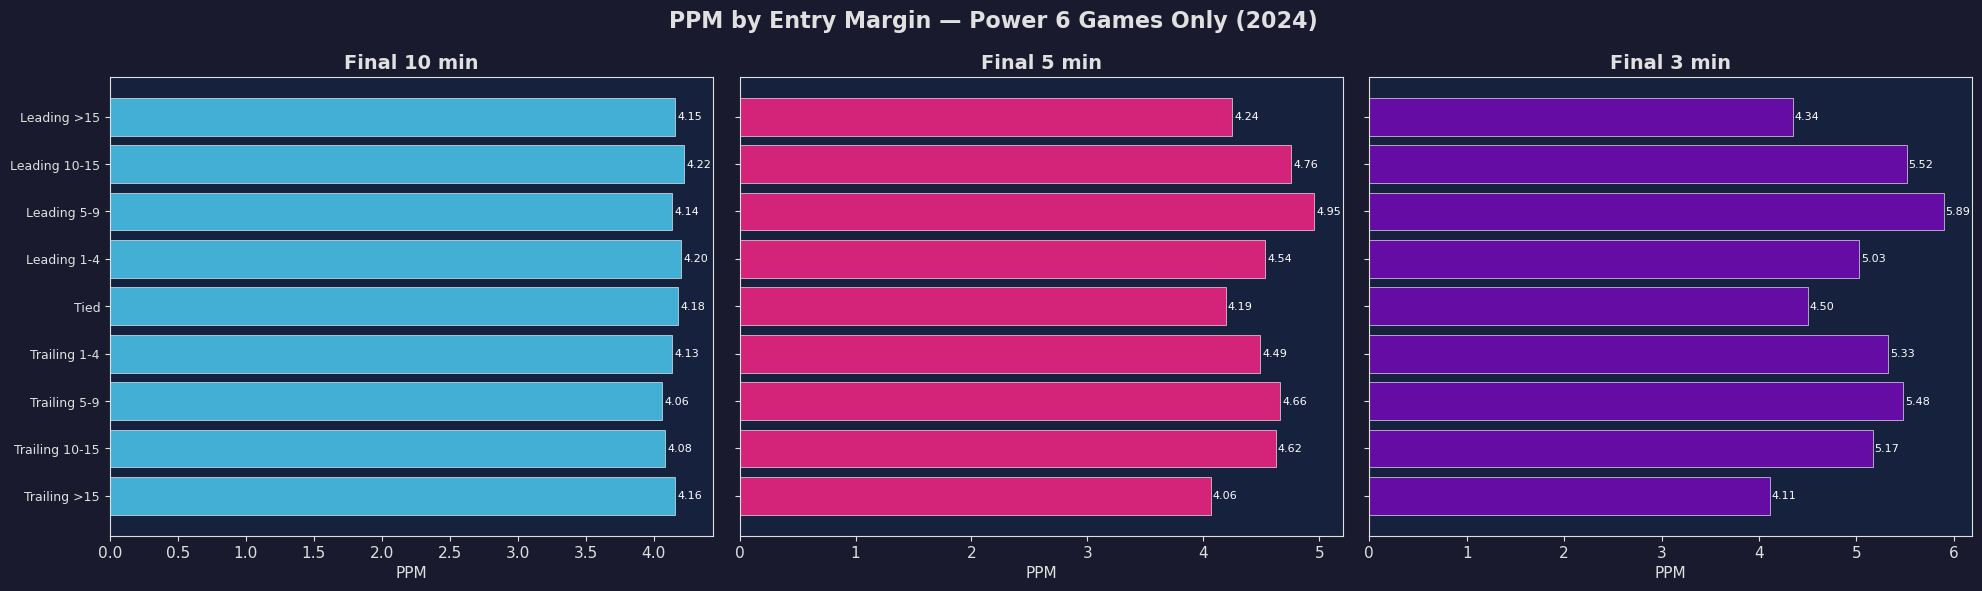

Saved: viz_p6_table_a.png


In [67]:
# ── VIZ 1: PPM by Entry Margin per Window ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle(f'PPM by Entry Margin — Power 6 Games Only ({SEASON})',
             fontsize=16, fontweight='bold')
for ax, wl in zip(axes, ['Final 10 min','Final 5 min','Final 3 min']):
    data = table_a[table_a['Window']==wl].set_index('Margin Bucket').reindex(BUCKET_ORDER)
    ax.barh(range(len(BUCKET_ORDER)), data['PPM'].values, color=COLORS[wl],
            alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(BUCKET_ORDER)))
    ax.set_yticklabels(BUCKET_ORDER, fontsize=9)
    ax.set_xlabel('PPM'); ax.set_title(wl, fontweight='bold'); ax.invert_yaxis()
    for i, v in enumerate(data['PPM'].values):
        if not np.isnan(v): ax.text(v+0.02, i, f'{v:.2f}', va='center', fontsize=8, color='white')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_p6_table_a.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_p6_table_a.png')

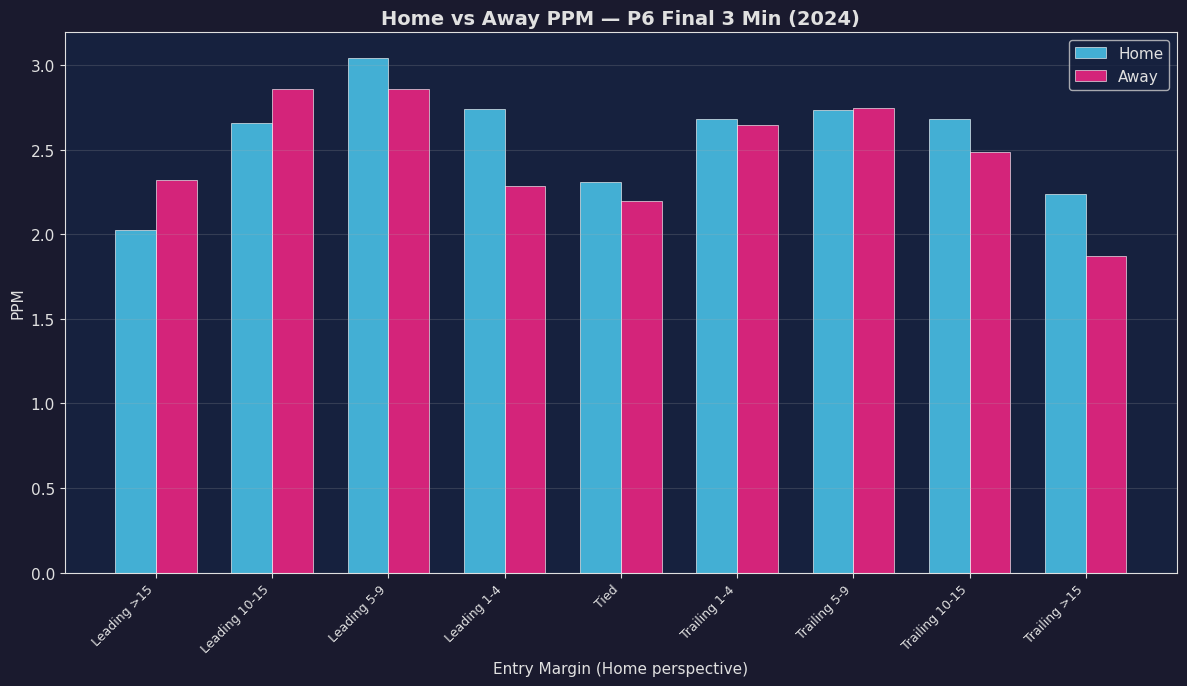

Saved: viz_p6_table_b.png


In [68]:
# ── VIZ 2: Home vs Away (Final 3 min) ──
fig, ax = plt.subplots(figsize=(12, 7))
tb_f3 = table_b[table_b['Window']=='Final 3 min']
x = np.arange(len(BUCKET_ORDER)); w = 0.35
hp = [tb_f3[(tb_f3['Margin Bucket']==b)&(tb_f3['Venue']=='Home')]['PPM'].values[0] for b in BUCKET_ORDER]
ap = [tb_f3[(tb_f3['Margin Bucket']==b)&(tb_f3['Venue']=='Away')]['PPM'].values[0] for b in BUCKET_ORDER]
ax.bar(x-w/2, hp, w, label='Home', color='#4cc9f0', alpha=0.85, edgecolor='white', linewidth=0.5)
ax.bar(x+w/2, ap, w, label='Away', color='#f72585', alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Entry Margin (Home perspective)'); ax.set_ylabel('PPM')
ax.set_title(f'Home vs Away PPM — P6 Final 3 Min ({SEASON})', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(BUCKET_ORDER, rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right'); ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_p6_table_b.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_p6_table_b.png')

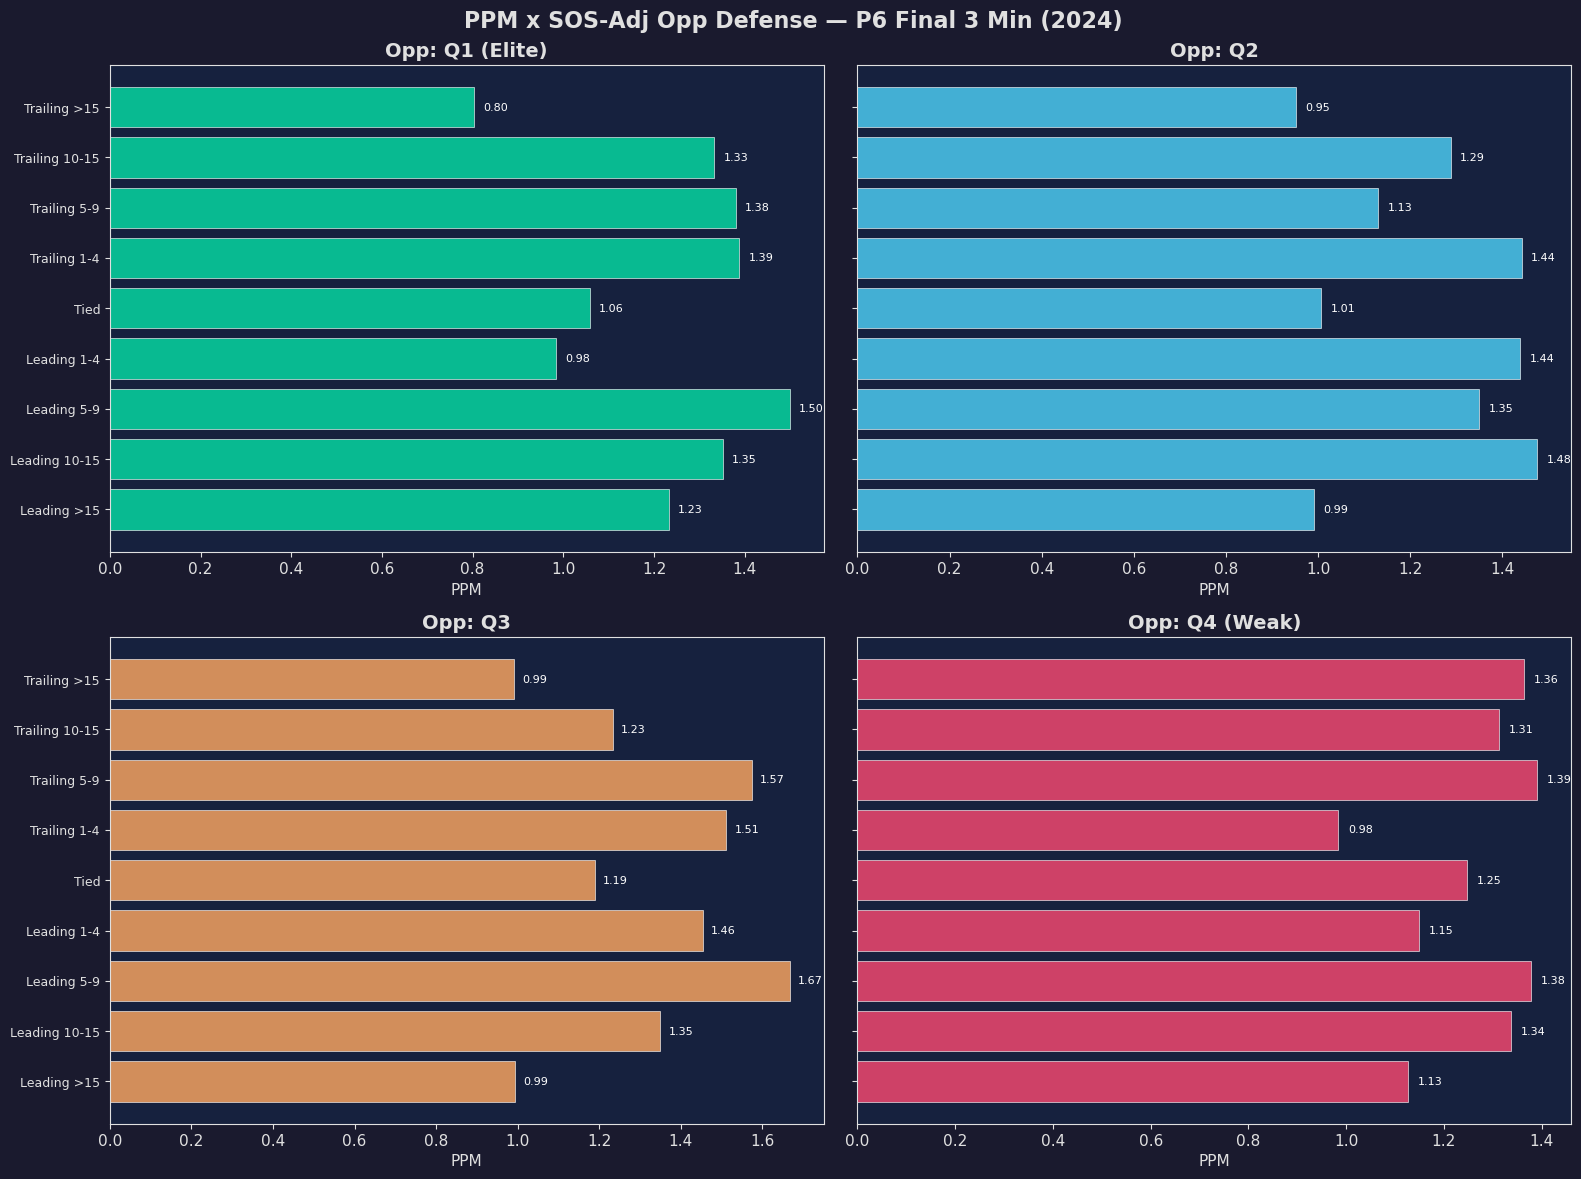

Saved: viz_p6_table_c.png


In [69]:
# ── VIZ 3: Defense Quartile Faceted (Final 3 min) ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
fig.suptitle(f'PPM x SOS-Adj Opp Defense — P6 Final 3 Min ({SEASON})',
             fontsize=16, fontweight='bold')
qc = {'Q1 (Elite)':'#06d6a0','Q2':'#4cc9f0','Q3':'#f4a261','Q4 (Weak)':'#ef476f'}
tc_f3 = table_c[table_c['Window']=='Final 3 min']
for ax, q in zip(axes.flat, ['Q1 (Elite)','Q2','Q3','Q4 (Weak)']):
    qd = tc_f3[tc_f3['Opp Defense']==q].set_index('Margin Bucket').reindex(BUCKET_ORDER)
    ax.barh(range(len(BUCKET_ORDER)), qd['PPM'].values, color=qc[q],
            alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(BUCKET_ORDER))); ax.set_yticklabels(BUCKET_ORDER, fontsize=9)
    ax.set_xlabel('PPM'); ax.set_title(f'Opp: {q}', fontweight='bold'); ax.invert_yaxis()
    for i, v in enumerate(qd['PPM'].values):
        if not np.isnan(v): ax.text(v+0.02, i, f'{v:.2f}', va='center', fontsize=8, color='white')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_p6_table_c.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_p6_table_c.png')

---
## 7 — P6 vs Full Dataset Comparison

In [70]:
# ── Load the full-dataset Table A from 02_analysis for comparison ──
# Re-compute full-dataset PPM using same methodology
pbp_full = pbp.copy()
reg_full = pbp_full[pbp_full['period_number'].isin([1,2])].copy()
reg_full['home_score'] = pd.to_numeric(reg_full['home_score'], errors='coerce').fillna(0).astype(int)
reg_full['away_score'] = pd.to_numeric(reg_full['away_score'], errors='coerce').fillna(0).astype(int)
reg_full['score_value'] = pd.to_numeric(reg_full['score_value'], errors='coerce').fillna(0).astype(int)
reg_full['secs_remaining'] = pd.to_numeric(reg_full['end_game_seconds_remaining'], errors='coerce')
reg_full['margin'] = reg_full['home_score'] - reg_full['away_score']
reg_full = reg_full.sort_values(['game_id','sequence_number']).reset_index(drop=True)

entry_full_3 = get_entry_margins(reg_full, 180).apply(margin_bucket)

full_scoring = reg_full[(reg_full['scoring_play']==True) & (reg_full['secs_remaining']<=180)].copy()
full_scoring['entry_bucket'] = full_scoring['game_id'].map(entry_full_3)
full_scoring = full_scoring.dropna(subset=['entry_bucket'])

full_pts = full_scoring.groupby('entry_bucket')['score_value'].sum()
full_games = entry_full_3.value_counts()

rows = []
for b in BUCKET_ORDER:
    p6_row = table_a[(table_a['Window']=='Final 3 min')&(table_a['Margin Bucket']==b)]
    p6_ppm = p6_row['PPM'].values[0] if len(p6_row) > 0 else 0
    f_pts = full_pts.get(b, 0)
    f_ng = full_games.get(b, 0)
    f_ppm = f_pts / (f_ng * 3) if f_ng > 0 else 0
    rows.append({'Margin Bucket': b, 'PPM (All Games)': round(f_ppm, 3),
                 'PPM (P6 Only)': p6_ppm, 'Delta': round(p6_ppm - f_ppm, 3)})

comp = pd.DataFrame(rows)
n_full = reg_full['game_id'].nunique()
print(f'=== PPM Comparison: Final 3 Min ===')
print(f'    All games: {n_full:,} | P6 only: {n_games:,}\n')
display(comp)

=== PPM Comparison: Final 3 Min ===
    All games: 6,151 | P6 only: 1,041



,Margin Bucket,PPM (All Games),PPM (P6 Only),Delta
0,Leading >15,4.159,4.344,0.185
1,Leading 10-15,5.094,5.516,0.422
2,Leading 5-9,5.479,5.895,0.416
3,Leading 1-4,5.032,5.028,-0.004
4,Tied,4.471,4.503,0.032
5,Trailing 1-4,5.034,5.326,0.292
6,Trailing 5-9,5.521,5.478,-0.043
7,Trailing 10-15,5.308,5.167,-0.141
8,Trailing >15,4.183,4.110,-0.073


---
## 8 — Robustness Checks

In [71]:
# ── 8a: Extended conference set (P6 + AAC/MWC/A10/WCC) ──
EXT_CONFS = POWER_6 + ['American', 'Mountain West', 'A-10', 'WCC']
ext_teams = team_conf[team_conf['conf'].isin(EXT_CONFS)]
ext_ids = set(ext_teams['team_id'])
ext_games = schedule[
    schedule['home_id'].isin(ext_ids) & schedule['away_id'].isin(ext_ids)
]['game_id'].unique()

reg_ext = pbp[pbp['game_id'].isin(ext_games) & pbp['period_number'].isin([1,2])].copy()
reg_ext['home_score'] = pd.to_numeric(reg_ext['home_score'], errors='coerce').fillna(0).astype(int)
reg_ext['away_score'] = pd.to_numeric(reg_ext['away_score'], errors='coerce').fillna(0).astype(int)
reg_ext['score_value'] = pd.to_numeric(reg_ext['score_value'], errors='coerce').fillna(0).astype(int)
reg_ext['secs_remaining'] = pd.to_numeric(reg_ext['end_game_seconds_remaining'], errors='coerce')
reg_ext['margin'] = reg_ext['home_score'] - reg_ext['away_score']
reg_ext = reg_ext.sort_values(['game_id','sequence_number']).reset_index(drop=True)

ext_entry_3 = get_entry_margins(reg_ext, 180).apply(margin_bucket)
ext_scoring = reg_ext[(reg_ext['scoring_play']==True) & (reg_ext['secs_remaining']<=180)].copy()
ext_scoring['entry_bucket'] = ext_scoring['game_id'].map(ext_entry_3)
ext_scoring = ext_scoring.dropna(subset=['entry_bucket'])

ext_pts = ext_scoring.groupby('entry_bucket')['score_value'].sum()
ext_gb = ext_entry_3.value_counts()
n_ext = reg_ext['game_id'].nunique()

ext_rows = []
for b in BUCKET_ORDER:
    p6v = table_a[(table_a['Window']=='Final 3 min')&(table_a['Margin Bucket']==b)]['PPM'].values[0]
    ep = ext_pts.get(b, 0)
    eg = ext_gb.get(b, 0)
    eppm = ep / (eg * 3) if eg > 0 else 0
    ext_rows.append({'Margin Bucket': b, 'PPM (P6)': p6v, 'PPM (Extended)': round(eppm, 3)})

print(f'=== Sensitivity: P6 ({n_games} games) vs Extended ({n_ext} games), Final 3 Min ===')
display(pd.DataFrame(ext_rows))

=== Sensitivity: P6 (1041 games) vs Extended (1707 games), Final 3 Min ===


,Margin Bucket,PPM (P6),PPM (Extended)
0,Leading >15,4.344,4.266
1,Leading 10-15,5.516,5.433
2,Leading 5-9,5.895,5.858
3,Leading 1-4,5.028,5.003
4,Tied,4.503,4.588
5,Trailing 1-4,5.326,5.205
6,Trailing 5-9,5.478,5.537
7,Trailing 10-15,5.167,5.103
8,Trailing >15,4.110,4.236


In [72]:
# ── 8b: OT verification ──
ot = pbp_p6[pbp_p6['period_number'] > 2]
print(f'P6 games with OT: {ot["game_id"].nunique()} / {pbp_p6["game_id"].nunique()}')
print(f'OT events excluded: {len(ot):,}')

P6 games with OT: 66 / 1041
OT events excluded: 3,732


---
## 8c — Full-Game PPM by Opponent Defense Quartile

PPM across the full flow of the game, ignoring margin,
sliced only by **opponent SOS-adjusted defense quartile**.

In [73]:
# ── Full-game PPM by time segment x opponent defense quartile ──
# All scoring events in regulation (P6 games)
all_scoring = reg[reg['scoring_play'] == True].copy()
all_scoring['opp_team_id'] = np.where(
    all_scoring['scorer_is_home'],
    all_scoring['away_team_id'],
    all_scoring['home_team_id']
)
all_scoring['opp_def_q'] = all_scoring['opp_team_id'].map(def_lookup)
all_scoring = all_scoring.dropna(subset=['opp_def_q'])

# Time segments
TIME_SEGS = [
    ('Full Game',  0, 2400),
    ('1st Half', 1200, 2400),
    ('2nd Half',   0, 1200),
    ('Final 10',   0,  600),
    ('Final 5',    0,  300),
    ('Final 3',    0,  180),
]

# Count team-game observations per quartile (each game = 2 team-games)
game_tm = reg.groupby('game_id').first()[['home_team_id', 'away_team_id']].copy()
game_tm['home_opp_q'] = game_tm['away_team_id'].map(def_lookup)
game_tm['away_opp_q'] = game_tm['home_team_id'].map(def_lookup)
q_counts = pd.concat([game_tm['home_opp_q'].dropna(), game_tm['away_opp_q'].dropna()]).value_counts()

rows = []
for seg_name, lo, hi in TIME_SEGS:
    seg_mins = (hi - lo) / 60
    seg_events = all_scoring[
        (all_scoring['secs_remaining'] >= lo) & (all_scoring['secs_remaining'] <= hi)
    ]
    pts_by_q = seg_events.groupby('opp_def_q')['score_value'].sum()
    for q in ['Q1 (Elite)', 'Q2', 'Q3', 'Q4 (Weak)']:
        pts = pts_by_q.get(q, 0)
        n_tg = q_counts.get(q, 0)
        ppm = pts / (n_tg * seg_mins) if n_tg > 0 and seg_mins > 0 else 0
        rows.append({'Segment': seg_name, 'Opp Defense': q,
                     'Team-Games': n_tg, 'Total Pts': int(pts), 'PPM': round(ppm, 3)})

full_flow = pd.DataFrame(rows)
pivot_flow = full_flow.pivot_table(
    index='Opp Defense', columns='Segment', values='PPM', sort=False
)[['Full Game', '1st Half', '2nd Half', 'Final 10', 'Final 5', 'Final 3']]

print(f'=== Full-Game PPM Flow by Opp Defense Quartile (P6 Only) ===')
print(f'    No margin bucketing — pure scoring rate vs opponent strength\n')
display(pivot_flow)
print(f'\nTeam-games per quartile: {q_counts.sort_index().to_dict()}')

=== Full-Game PPM Flow by Opp Defense Quartile (P6 Only) ===
    No margin bucketing — pure scoring rate vs opponent strength



Segment,Full Game,1st Half,2nd Half,Final 10,Final 5,Final 3
Opp Defense,,,,,,
Q1 (Elite),1.709,1.621,1.831,1.961,2.137,2.390
Q2,1.775,1.684,1.902,2.030,2.224,2.432
Q3,1.851,1.770,1.971,2.116,2.349,2.619
Q4 (Weak),1.950,1.869,2.072,2.201,2.396,2.646



Team-games per quartile: {'Q1 (Elite)': 539, 'Q2': 528, 'Q3': 524, 'Q4 (Weak)': 491}


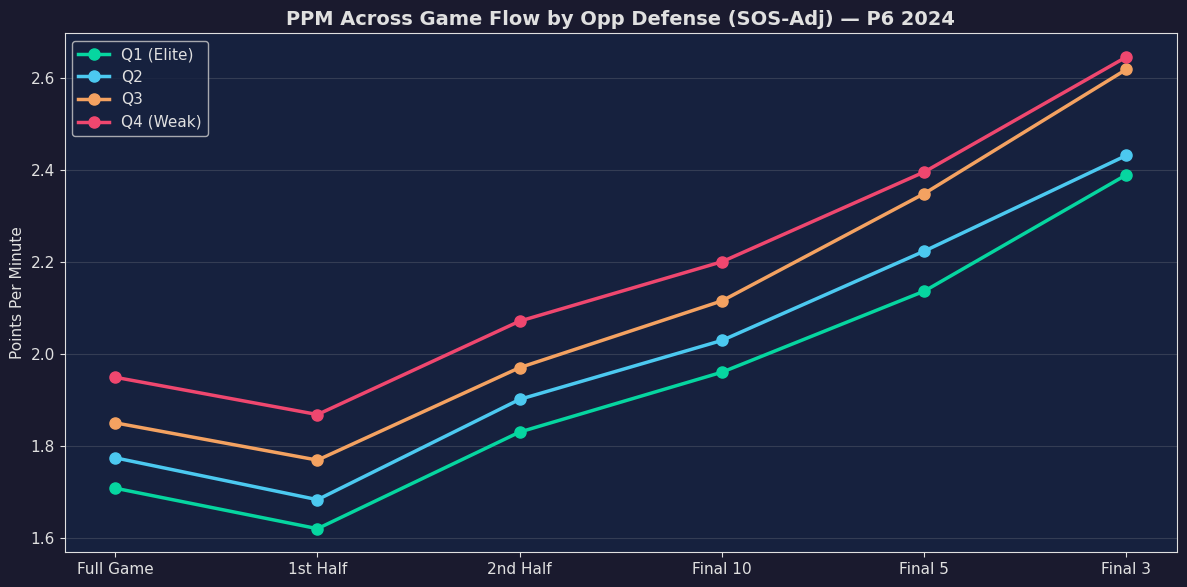

Saved: viz_p6_flow_by_def.png


In [74]:
# ── VIZ: Full-game flow line chart ──
fig, ax = plt.subplots(figsize=(12, 6))
qc = {'Q1 (Elite)': '#06d6a0', 'Q2': '#4cc9f0', 'Q3': '#f4a261', 'Q4 (Weak)': '#ef476f'}
seg_labels = ['Full Game', '1st Half', '2nd Half', 'Final 10', 'Final 5', 'Final 3']

for q in ['Q1 (Elite)', 'Q2', 'Q3', 'Q4 (Weak)']:
    vals = [pivot_flow.loc[q, s] for s in seg_labels]
    ax.plot(seg_labels, vals, 'o-', label=q, color=qc[q], linewidth=2.5, markersize=8)

ax.set_ylabel('Points Per Minute')
ax.set_title(f'PPM Across Game Flow by Opp Defense (SOS-Adj) — P6 {SEASON}', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_p6_flow_by_def.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_p6_flow_by_def.png')

---
## 8d — Minute-by-Minute PPM (All 40 Minutes)

PPM for each individual game minute (1 through 40), by opponent defense quartile.
Game minute 1 = start of game, minute 40 = final minute of regulation.

In [75]:
# ── Minute-by-minute PPM across all 40 regulation minutes ──
# Game minute 1 = secs 2400-2340, minute 2 = 2340-2280, ... minute 40 = 60-0
minute_rows = []
for game_min in range(1, 41):
    hi = 2400 - (game_min - 1) * 60  # top of this minute
    lo = 2400 - game_min * 60         # bottom of this minute
    seg_events = all_scoring[
        (all_scoring['secs_remaining'] > lo) & (all_scoring['secs_remaining'] <= hi)
    ]
    pts_by_q = seg_events.groupby('opp_def_q')['score_value'].sum()
    for q in ['Q1 (Elite)', 'Q2', 'Q3', 'Q4 (Weak)']:
        pts = pts_by_q.get(q, 0)
        n_tg = q_counts.get(q, 0)
        ppm = pts / n_tg if n_tg > 0 else 0  # 1 minute window, so PPM = pts/games
        minute_rows.append({'Game Minute': game_min, 'Opp Defense': q,
                            'Total Pts': int(pts), 'PPM': round(ppm, 3)})

min_df = pd.DataFrame(minute_rows)

# Display table for last 10 minutes
print('=== PPM by Individual Game Minute x Opp Defense (Last 10 Minutes) ===')
last10 = min_df[min_df['Game Minute'] >= 31].pivot_table(
    index='Game Minute', columns='Opp Defense', values='PPM', sort=False
)[['Q1 (Elite)', 'Q2', 'Q3', 'Q4 (Weak)']]
display(last10)

=== PPM by Individual Game Minute x Opp Defense (Last 10 Minutes) ===


Opp Defense,Q1 (Elite),Q2,Q3,Q4 (Weak)
Game Minute,,,,
31,1.833,1.790,1.861,2.047
32,1.837,1.890,1.893,2.024
33,1.647,1.769,1.924,1.990
34,1.788,1.714,1.912,1.969
35,1.818,2.015,1.821,1.996
36,1.796,1.966,1.975,2.151
37,1.716,1.858,1.914,1.892
38,1.872,1.871,2.135,2.077
39,2.056,2.142,2.294,2.299


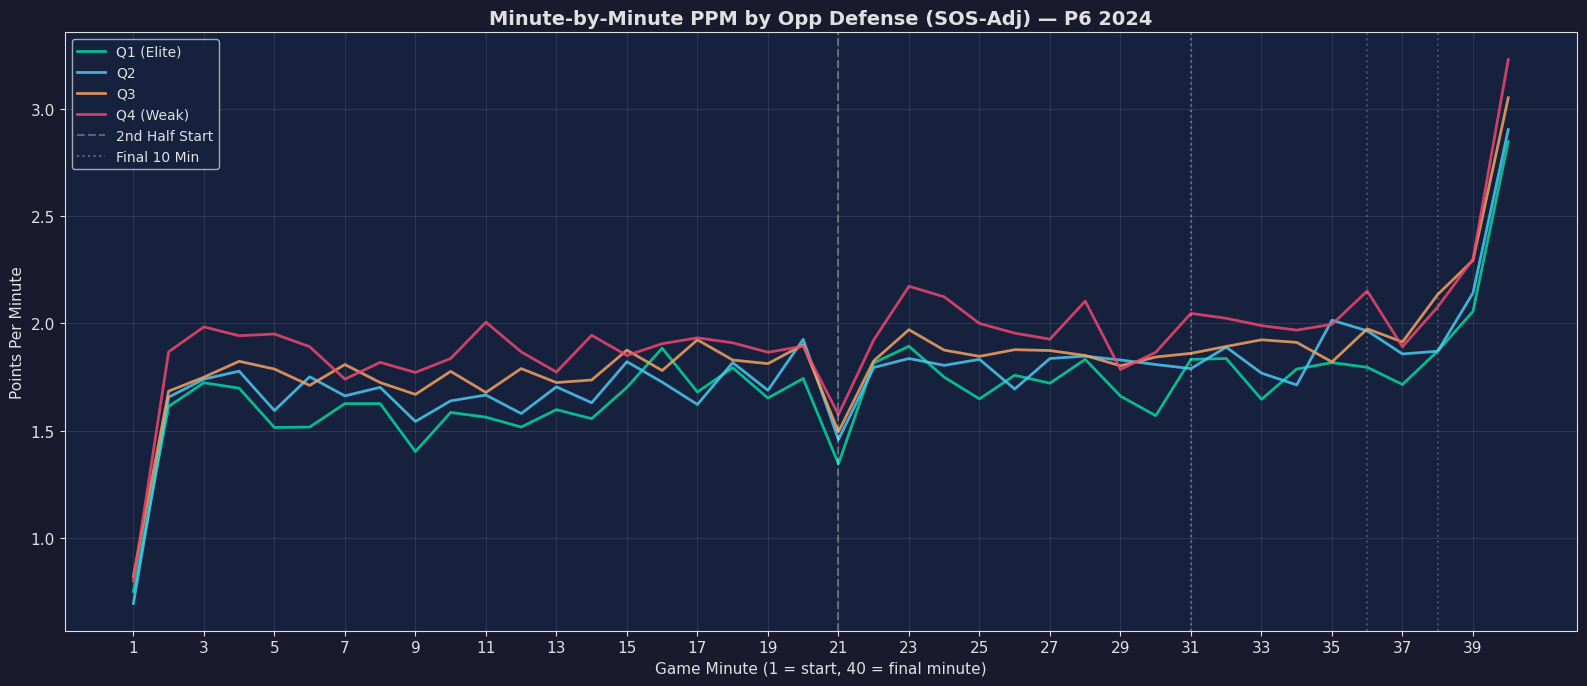

Saved: viz_p6_minute_by_minute.png


In [76]:
# ── VIZ: Minute-by-minute PPM line chart (all 40 minutes) ──
fig, ax = plt.subplots(figsize=(16, 7))
qc = {'Q1 (Elite)': '#06d6a0', 'Q2': '#4cc9f0', 'Q3': '#f4a261', 'Q4 (Weak)': '#ef476f'}

for q in ['Q1 (Elite)', 'Q2', 'Q3', 'Q4 (Weak)']:
    q_data = min_df[min_df['Opp Defense'] == q].sort_values('Game Minute')
    ax.plot(q_data['Game Minute'], q_data['PPM'], '-', label=q, color=qc[q],
            linewidth=2, alpha=0.85)

# Add vertical lines for key moments
ax.axvline(x=21, color='white', linestyle='--', alpha=0.3, label='2nd Half Start')
ax.axvline(x=31, color='white', linestyle=':', alpha=0.3, label='Final 10 Min')
ax.axvline(x=36, color='white', linestyle=':', alpha=0.2)
ax.axvline(x=38, color='white', linestyle=':', alpha=0.2)

ax.set_xlabel('Game Minute (1 = start, 40 = final minute)')
ax.set_ylabel('Points Per Minute')
ax.set_title(f'Minute-by-Minute PPM by Opp Defense (SOS-Adj) — P6 {SEASON}',
             fontweight='bold', fontsize=14)
ax.set_xticks(range(1, 41, 2))
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='both', alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_p6_minute_by_minute.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_p6_minute_by_minute.png')

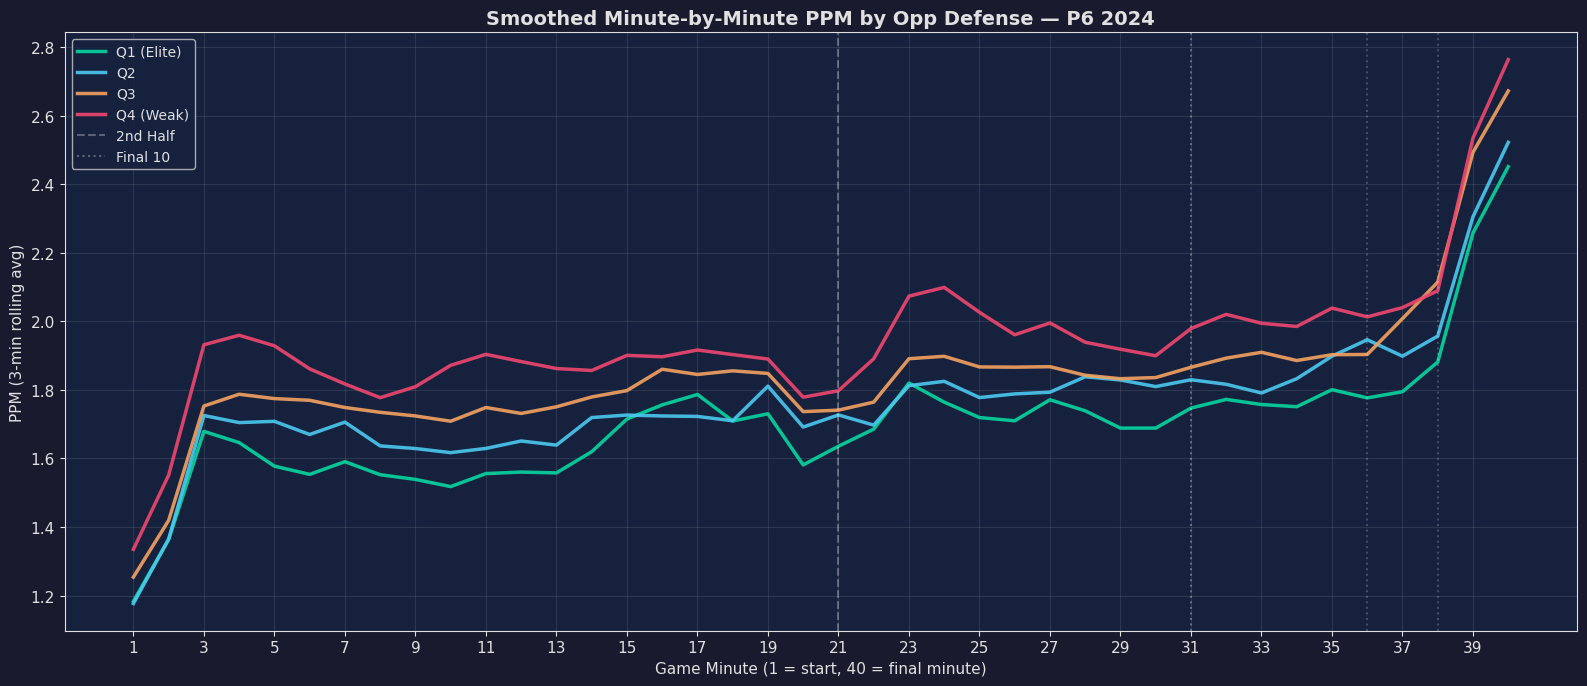

Saved: viz_p6_minute_smoothed.png


In [77]:
# ── VIZ: Smoothed version (3-minute rolling average) ──
fig, ax = plt.subplots(figsize=(16, 7))

for q in ['Q1 (Elite)', 'Q2', 'Q3', 'Q4 (Weak)']:
    q_data = min_df[min_df['Opp Defense'] == q].sort_values('Game Minute').copy()
    q_data['PPM_smooth'] = q_data['PPM'].rolling(3, center=True, min_periods=1).mean()
    ax.plot(q_data['Game Minute'], q_data['PPM_smooth'], '-', label=q, color=qc[q],
            linewidth=2.5, alpha=0.9)

ax.axvline(x=21, color='white', linestyle='--', alpha=0.3, label='2nd Half')
ax.axvline(x=31, color='white', linestyle=':', alpha=0.3, label='Final 10')
ax.axvline(x=36, color='white', linestyle=':', alpha=0.2)
ax.axvline(x=38, color='white', linestyle=':', alpha=0.2)

ax.set_xlabel('Game Minute (1 = start, 40 = final minute)')
ax.set_ylabel('PPM (3-min rolling avg)')
ax.set_title(f'Smoothed Minute-by-Minute PPM by Opp Defense — P6 {SEASON}',
             fontweight='bold', fontsize=14)
ax.set_xticks(range(1, 41, 2))
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='both', alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_p6_minute_smoothed.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_p6_minute_smoothed.png')

---
## 10 — Summary

In [78]:
print('='*60)
print(f'  P6 ENDGAME ANALYSIS — {SEASON} Season')
print('='*60)
print(f'\n  P6 games analyzed:       {n_games:,}')
print(f'  P6 teams:                {len(p6_stats)}')
print(f'  SOS iterations:          {N_ITER}')
print(f'  Def quartiles:           P6 subset of SOS-adjusted ratings')
print(f'\n  Methodology: snapshot entry margin, same as 02_analysis')
print(f'  Outputs: Tables A/B/C, 3 visualizations, P6 vs Full comparison')

  P6 ENDGAME ANALYSIS — 2024 Season

  P6 games analyzed:       1,041
  P6 teams:                80
  SOS iterations:          15
  Def quartiles:           P6 subset of SOS-adjusted ratings

  Methodology: snapshot entry margin, same as 02_analysis
  Outputs: Tables A/B/C, 3 visualizations, P6 vs Full comparison
